Load and explore the dataset

In [1]:
import pandas as pd 
import json 
import re

In [2]:
#### load data
meta_articles = pd.read_parquet("parquet_data/corpus_nl.parquet")
meta_qa = pd.read_parquet("parquet_data/qa_nl.parquet")

Explore number of tokens per articles

In [3]:
import tiktoken

enc = tiktoken.encoding_for_model("text-embedding-3-small")
art_texts = meta_articles.article.to_list()
num_tokens_full = []
for text in art_texts:
    num_tokens = len(enc.encode(text))
    num_tokens_full.append(num_tokens)
pd.Series(num_tokens_full).describe()

count    26014.000000
mean       314.491120
std        443.297734
min          4.000000
25%         93.000000
50%        176.000000
75%        358.000000
max       7957.000000
dtype: float64

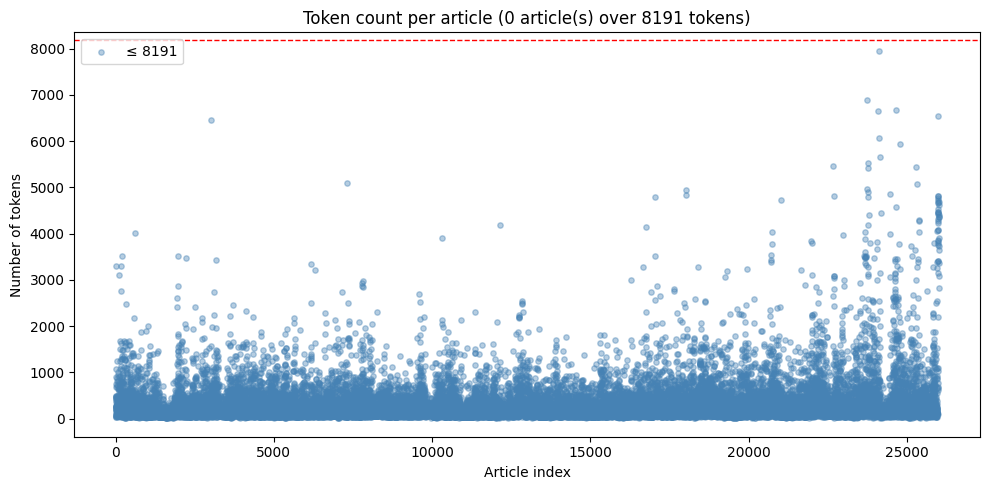

0 article(s) exceed 8191 tokens:


In [4]:
import matplotlib.pyplot as plt

threshold = 8191
over_limit = [(i, n) for i, n in enumerate(num_tokens_full) if n > threshold]

plt.figure(figsize=(10, 5))
plt.scatter(range(len(num_tokens_full)), num_tokens_full, alpha=0.4, s=15, color='steelblue', label='≤ 8191')

if over_limit:
    xs, ys = zip(*over_limit)
    plt.scatter(xs, ys, color='red', s=40, label='> 8191', zorder=3)
    for x, y in over_limit:
        plt.annotate(str(x), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1)
plt.xlabel("Article index")
plt.ylabel("Number of tokens")
plt.title(f"Token count per article ({len(over_limit)} article(s) over {threshold} tokens)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{len(over_limit)} article(s) exceed {threshold} tokens:")
for i, n in over_limit:
    print(f"  index {i}: {n} tokens")

Embedding Vectorstore

In [5]:
from openai import OpenAI
import numpy as np
from tqdm import tqdm
import time
from openai import RateLimitError

def embed_batch(texts: list[str], max_retries=10) -> np.ndarray:
    for attempt in range(max_retries):
        try:
            response = client.embeddings.create(
                model=model,
                input=texts
            )
            return np.array(
                [d.embedding for d in response.data],
                dtype=np.float32
            )

        except RateLimitError:
            wait = min(2 ** attempt, 30)  # 1, 2, 4, 8, 16, 30...
            print(f"Rate limit hit. Waiting {wait}s...")
            time.sleep(wait)

    raise RuntimeError("Maximum retries exceeded.")


def build_index(doc_texts: list[str], batch_size: int = 256) -> np.ndarray:
    """
    It embeds an entire collection of documents
    Embed the full corpus in batches with a progress bar.
    """
    chunks = []
    for i in tqdm(range(0, len(doc_texts), batch_size), desc="Embedding"):
        chunks.append(embed_batch(doc_texts[i : i + batch_size]))
    return np.vstack(chunks)  # stack batches into one (N, 1536) matrix


In [6]:
art_texts = meta_articles.article.to_list()

In [7]:
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key= os.getenv("OPENAI_API"))
model = "text-embedding-3-small"
embeddings_path = "indexes/dense/embeddings.npy"
if Path(embeddings_path).exists():
    print(f"Loading cached embeddings from {embeddings_path}")
    doc_embeddings = np.load(embeddings_path)
else:
    print(f"Embedding {len(art_texts)} docs (~$0.22 at text-embedding-3-small)")
    doc_embeddings = build_index(art_texts)
    np.save(embeddings_path, doc_embeddings)

# Pre-normalize once so cosine similarity becomes a single dot product later.
doc_embeddings_normed = doc_embeddings / np.linalg.norm(
    doc_embeddings, axis=1, keepdims=True)

Embedding 26014 docs (~$0.22 at text-embedding-3-small)


Embedding:  23%|██▎       | 23/102 [00:24<01:52,  1.42s/it]

Rate limit hit. Waiting 1s...


Embedding:  33%|███▎      | 34/102 [01:02<03:00,  2.66s/it]

Rate limit hit. Waiting 1s...


...

Rate limit hit. Waiting 1s...


Embedding:  99%|█████████▉| 101/102 [05:30<00:04,  4.24s/it]

Rate limit hit. Waiting 1s...


Embedding: 100%|██████████| 102/102 [05:45<00:00,  3.39s/it]


FileNotFoundError: [Errno 2] No such file or directory: 'indexes/dense/embeddings.npy'

In [9]:
np.save(Path(embeddings_path), doc_embeddings)

Test code

In [1]:
query1 = "Ik wil scheiden wegens onherstelbare ontwrichting. Kan ik een tijdslimiet vastleggen voor de alimentatie?"
query2 = "Mijn wettelijk samenwonende partner is overleden. Wat zijn mijn rechten in zijn nalatenschap?"
query3 = "Ik ben ouder. Kan ik de alimentatie indexeren? Hoe bereken ik deze indexering?"

In [2]:
from agents import Agents
agent = Agents()
paraphrase = agent.paraphrase(query1)
print(paraphrase)

original_query='Ik wil scheiden wegens onherstelbare ontwrichting. Kan ik een tijdslimiet vastleggen voor de alimentatie?' paraphrased_queries=['Is het mogelijk om bij een echtscheiding op grond van onherstelbare ontwrichting een duur te bepalen voor de onderhoudsuitkering?', 'Mag er volgens Belgisch recht een beperking in tijd opgelegd worden aan alimentatie bij een scheiding wegens onherstelbare ontwrichting?', 'Kan de rechtbank in België een alimentatie voor een bepaalde periode opleggen bij een echtscheiding als gevolg van onherstelbare ontwrichting?']


In [3]:
print(paraphrase.paraphrased_queries)

['Is het mogelijk om bij een echtscheiding op grond van onherstelbare ontwrichting een duur te bepalen voor de onderhoudsuitkering?', 'Mag er volgens Belgisch recht een beperking in tijd opgelegd worden aan alimentatie bij een scheiding wegens onherstelbare ontwrichting?', 'Kan de rechtbank in België een alimentatie voor een bepaalde periode opleggen bij een echtscheiding als gevolg van onherstelbare ontwrichting?']


In [3]:
### test code from retriever.py
from retrievers import DenseRetriever
ds_retriever = DenseRetriever()
search_res = ds_retriever.search(query1, k=5)
print(search_res)

[(3600, 0.6451606750488281), (3604, 0.6056511402130127), (3957, 0.6003761291503906), (15393, 0.5961030721664429), (15363, 0.5907639265060425)]


In [4]:
from retrievers import DocsRetriever
doc_retriever = DocsRetriever(search_res)
print(doc_retriever.documents())

['Art. 229. § 1. De echtscheiding wordt uitgesproken wanneer de rechter vaststelt dat het huwelijk onherstelbaar ontwricht is. Het huwelijk is onherstelbaar ontwricht wanneer de voortzetting van het samenleven tussen de echtgenoten en de hervatting ervan redelijkerwijs onmogelijk is geworden ingevolge die ontwrichting. Het bewijs van de onherstelbare ontwrichting kan met alle wettelijke middelen worden geleverd. § 2. De onherstelbare ontwrichting bestaat wanneer de aanvraag gezamenlijk wordt gedaan door de twee echtgenoten, na meer dan zes maanden feitelijk gescheiden te zijn of wanneer de aanvraag tot tweemaal toe werd gedaan overeenkomstig artikel 1255, § 1, van het Gerechtelijk Wetboek. § 3. De onherstelbare ontwrichting bestaat ook wanneer de aanvraag wordt gedaan door één enkele echtgenoot na meer dan één jaar feitelijke scheiding of wanneer de aanvraag tot tweemaal toe werd gedaan overeenkomstig artikel 1255, § 2, van het Gerechtelijk Wetboek.', 'Art. 301. § 1. De echtgenoten kun

In [2]:
from retrievers import HybridRetriever
hyb_retriever = HybridRetriever(rrf_k=10)
search_res = hyb_retriever.hybrid_candidates(query1, k=5)
print(search_res)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[(3600, 0.18181818181818182), (27155, 0.08333333333333333), (3604, 0.08333333333333333), (3602, 0.07692307692307693), (3957, 0.07692307692307693)]
